In [11]:
# Task 5: Exploratory Data Analysis (EDA) - Titanic Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [12]:
# Load the Titanic training dataset
df = pd.read_csv("train.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [14]:
# Summary statistics
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
# Shape of dataset
print("Rows and columns:", df.shape)

Rows and columns: (891, 12)


In [16]:
# Shape of dataset
print("Rows and columns:", df.shape)

Rows and columns: (891, 12)


In [17]:
# Check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [18]:
# Count values of important columns
print("Survived:")
print(df["Survived"].value_counts())

print("\nGender:")
print(df["Sex"].value_counts())

print("\nPassenger Class:")
print(df["Pclass"].value_counts())

print("\nEmbarked:")
print(df["Embarked"].value_counts())

Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Gender:
Sex
male      577
female    314
Name: count, dtype: int64

Passenger Class:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


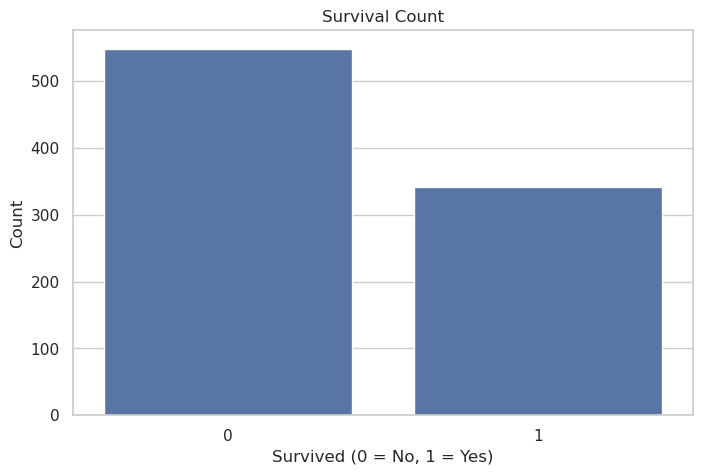

In [19]:
# Survival count
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

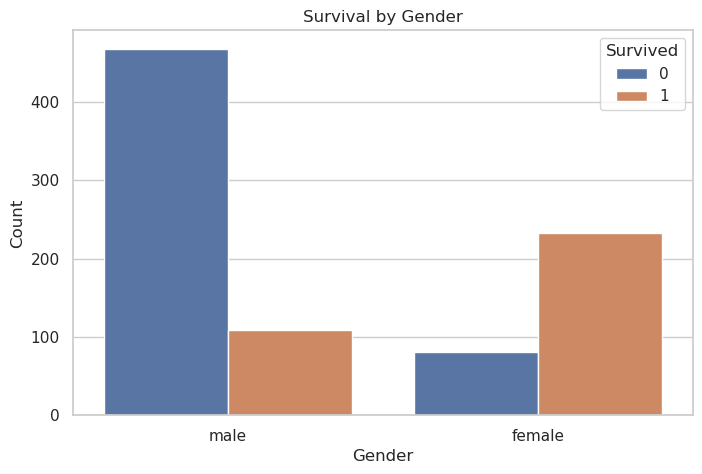

In [20]:
# Survival by gender
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

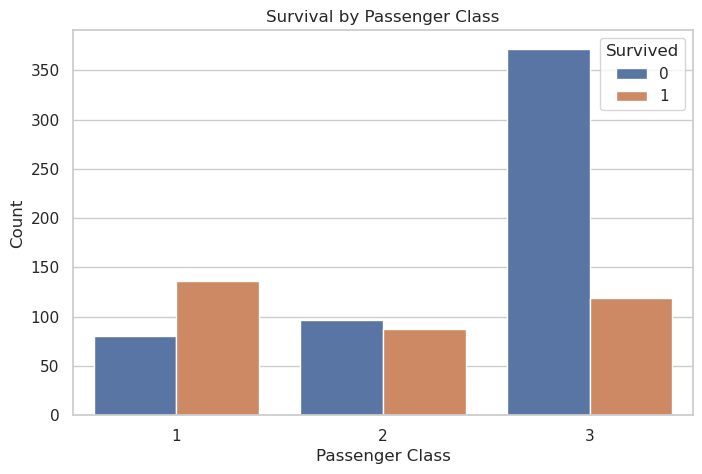

In [21]:
# Survival by passenger class
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

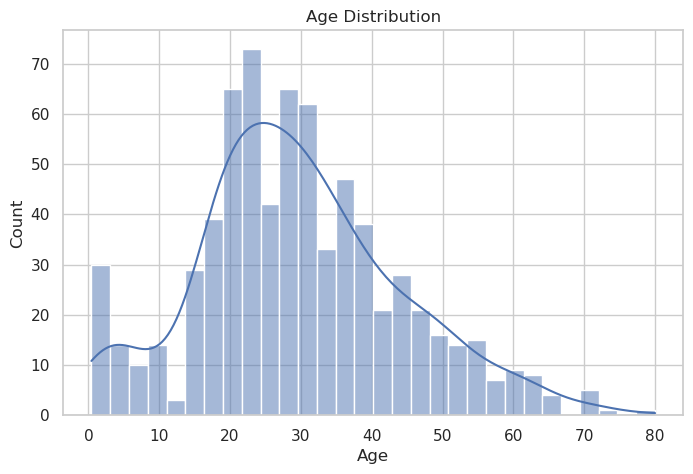

In [22]:
# Age distribution
sns.histplot(df["Age"].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

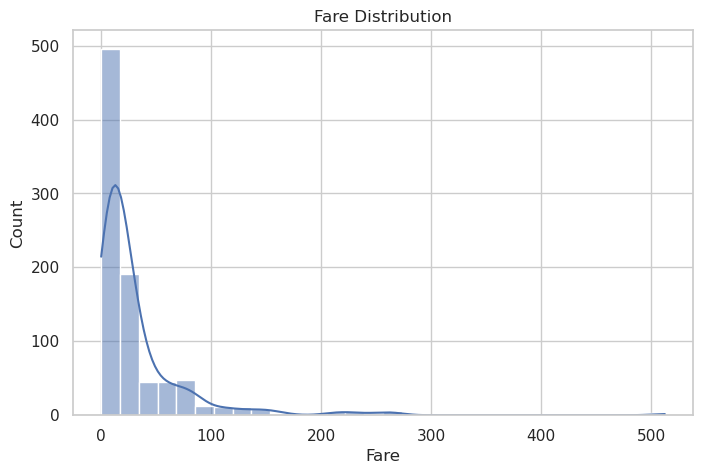

In [23]:
# Fare distribution
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

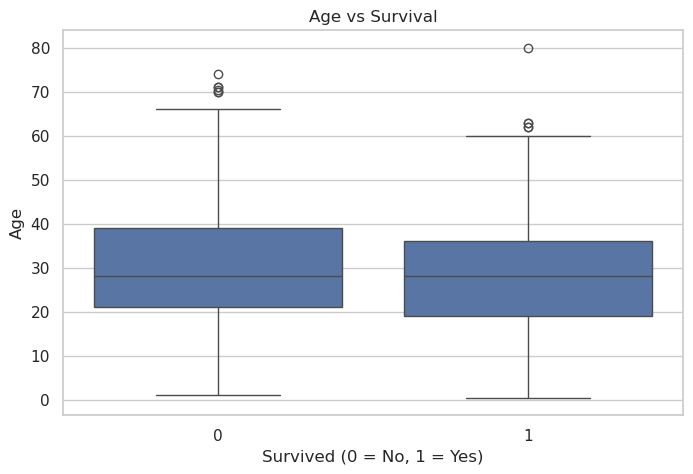

In [24]:
# Boxplot for Age and Survival
sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Age vs Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

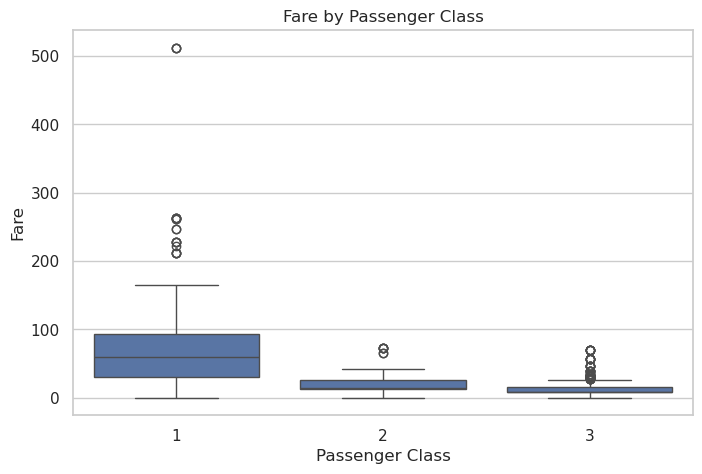

In [25]:
# Boxplot for Fare and Passenger Class
sns.boxplot(x="Pclass", y="Fare", data=df)
plt.title("Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

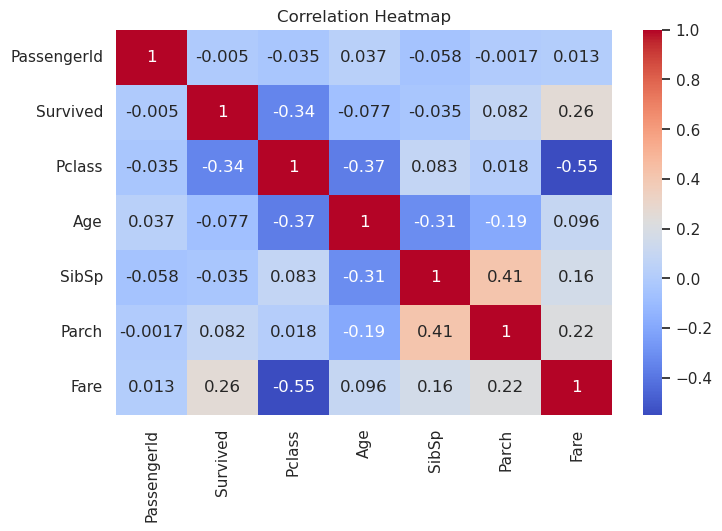

In [26]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

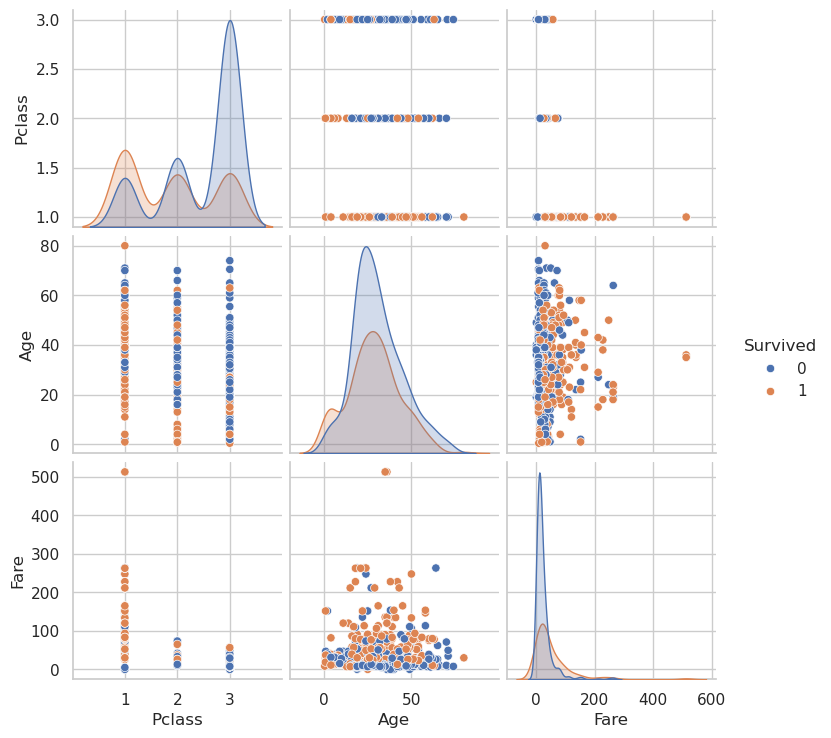

In [27]:
# Pairplot for selected numerical columns
sns.pairplot(df[["Survived", "Pclass", "Age", "Fare"]].dropna(), hue="Survived")
plt.show()

In [ ]:
# Survival rate by gender
df.groupby("Sex")["Survived"].mean()

In [ ]:
# Survival rate by passenger class
df.groupby("Pclass")["Survived"].mean()

In [28]:
# Survival rate by embarked station
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [29]:
# Final observations and summary

print("""
Observations:
1. Female passengers had a much higher survival rate than male passengers.
2. Passengers in 1st class had a better survival chance than passengers in 2nd and 3rd class.
3. The Age column has missing values.
4. Fare has some outliers because some passengers paid very high ticket prices.
5. Passenger class, gender, fare, and age appear to be important factors related to survival.
6. Most passengers did not survive.

Summary:
The Titanic dataset shows that survival was strongly influenced by gender and passenger class.
Females and 1st class passengers had higher survival chances.
The dataset also contains missing values and outliers, which are important to notice during EDA.
""")


Observations:
1. Female passengers had a much higher survival rate than male passengers.
2. Passengers in 1st class had a better survival chance than passengers in 2nd and 3rd class.
3. The Age column has missing values.
4. Fare has some outliers because some passengers paid very high ticket prices.
5. Passenger class, gender, fare, and age appear to be important factors related to survival.
6. Most passengers did not survive.

Summary:
The Titanic dataset shows that survival was strongly influenced by gender and passenger class.
Females and 1st class passengers had higher survival chances.
The dataset also contains missing values and outliers, which are important to notice during EDA.

